In [ ]:
# ELCT918 Lab 2 — Comparative Study of LeNet-5, AlexNet, and VGG16
# TensorFlow / Keras — CIFAR-10 and CIFAR-100

# ============================================================
# CELL 1 Install / import dependencies
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time


In [ ]:

# ============================================================
# CELL 2 — Build LeNet-5
#
# Based on the original LeNet-5 layer structure:
# C1 -> S2 -> C3 -> S4 -> C5 -> F6 -> Output
#
# CIFAR adaptation:
# - Input: 32x32x3 RGB instead of 32x32x1 grayscale
# - Output: num_classes (10 for CIFAR-10, 100 for CIFAR-100)
#
# S2 and S4:
# - Trainable subsampling layers
# - 2x2 non-overlapping regions
# - Each feature map has one trainable coefficient (alpha)
#   and one trainable bias (beta)
# ============================================================


class TrainableSubsampling(tf.keras.layers.Layer):

    def build(self, input_shape):

        # Number of feature maps/channels
        channels = input_shape[-1]

        # One trainable coefficient for each feature map
        self.alpha = self.add_weight(
            name="alpha",
            shape=(channels,),
            initializer="ones",
            trainable=True
        )

        # One trainable bias for each feature map
        self.beta = self.add_weight(
            name="beta",
            shape=(channels,),
            initializer="zeros",
            trainable=True
        )

    def call(self, inputs):

        # 2x2 non-overlapping subsampling
        # This adds the four values in each 2x2 region
        x = tf.nn.avg_pool2d(
            inputs,
            ksize=2,
            strides=2,
            padding="VALID"
        )

        # Convert average back to sum:
        # average * 4 = sum
        x = x * 4.0

        # Apply trainable coefficient and bias
        x = x * self.alpha + self.beta

        # Original LeNet uses sigmoid after subsampling
        return tf.nn.sigmoid(x)


def build_lenet(num_classes):

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(32, 32, 3)),

        # ----------------------------------------------------
        # C1
        # 6 feature maps
        # 5x5 convolution
        # ----------------------------------------------------
        tf.keras.layers.Conv2D(
            filters=6,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding="valid",
            activation="tanh"
        ),

        # ----------------------------------------------------
        # S2
        # Trainable subsampling
        # 2x2 non-overlapping regions
        # ----------------------------------------------------
        TrainableSubsampling(),

        # ----------------------------------------------------
        # C3
        # 16 feature maps
        # ----------------------------------------------------
        tf.keras.layers.Conv2D(
            filters=16,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding="valid",
            activation="tanh"
        ),

        # ----------------------------------------------------
        # S4
        # Trainable subsampling
        # ----------------------------------------------------
        TrainableSubsampling(),

        # ----------------------------------------------------
        # C5
        # 120 feature maps
        # ----------------------------------------------------
        tf.keras.layers.Conv2D(
            filters=120,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding="valid",
            activation="tanh"
        ),

        # ----------------------------------------------------
        # F6
        # Fully connected layer
        # ----------------------------------------------------
        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            units=84,
            activation="tanh"
        ),

        # ----------------------------------------------------
        # Output
        # ----------------------------------------------------
        tf.keras.layers.Dense(
            units=num_classes,
            activation="softmax"
        )
    ])

    return model




In [ ]:
# ============================================================
# CELL 3 — Build AlexNet
# Based on the original AlexNet structure:
# Conv1 -> Pool -> Conv2 -> Pool -> Conv3 -> Conv4 -> Conv5
# -> Pool -> FC6 -> FC7 -> Output
#
# CIFAR adaptation:
# - Input is 32x32x3.
# - The first convolution uses stride 1 rather than the original
#   large-image stride 4 so that CIFAR's small spatial dimensions
#   are not reduced too aggressively.
# - Final layer is 10 or 100 classes.
# ============================================================

def build_alexnet(num_classes):

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(32, 32, 3)),

        # Conv1
        tf.keras.layers.Conv2D(
            filters=96,
            kernel_size=(11, 11),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        # Pool 1
        tf.keras.layers.MaxPooling2D(
            pool_size=(3, 3),
            strides=(2, 2)
        ),

        # Conv2
        tf.keras.layers.Conv2D(
            filters=256,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        # Pool 2
        tf.keras.layers.MaxPooling2D(
            pool_size=(3, 3),
            strides=(2, 2)
        ),

        # Conv3
        tf.keras.layers.Conv2D(
            filters=384,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        # Conv4
        tf.keras.layers.Conv2D(
            filters=384,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        # Conv5
        tf.keras.layers.Conv2D(
            filters=256,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        # Pool 3
        tf.keras.layers.MaxPooling2D(
            pool_size=(3, 3),
            strides=(2, 2)
        ),

        # FC6
        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            units=4096,
            activation="relu"
        ),

        # FC7
        tf.keras.layers.Dense(
            units=4096,
            activation="relu"
        ),

        # Output
        tf.keras.layers.Dense(
            units=num_classes,
            activation="softmax"
        )
    ])

    return model


In [ ]:
# ============================================================
# CELL 4 — Build VGG16
# Based on VGG16:
# Block1: 2 conv
# Block2: 2 conv
# Block3: 3 conv
# Block4: 3 conv
# Block5: 3 conv
# followed by 3 fully-connected layers.
#
# CIFAR adaptation:
# - Input is 32x32x3.
# - Convolutions use 3x3 filters with same padding.
# - Final layer is 10 or 100 classes.
# ============================================================

def build_vgg16(num_classes):

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(32, 32, 3)),

        # ---------------- Block 1 ----------------
        tf.keras.layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(2, 2)
        ),

        # ---------------- Block 2 ----------------
        tf.keras.layers.Conv2D(
            filters=128,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.Conv2D(
            filters=128,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(2, 2)
        ),

        # ---------------- Block 3 ----------------
        tf.keras.layers.Conv2D(
            filters=256,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.Conv2D(
            filters=256,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.Conv2D(
            filters=256,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(2, 2)
        ),

        # ---------------- Block 4 ----------------
        tf.keras.layers.Conv2D(
            filters=512,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.Conv2D(
            filters=512,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.Conv2D(
            filters=512,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(2, 2)
        ),

        # ---------------- Block 5 ----------------
        tf.keras.layers.Conv2D(
            filters=512,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.Conv2D(
            filters=512,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.Conv2D(
            filters=512,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(2, 2)
        ),

        # ---------------- Fully connected layers ----------------
        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            units=4096,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            units=4096,
            activation="relu"
        ),

        # Output
        tf.keras.layers.Dense(
            units=num_classes,
            activation="softmax"
        )
    ])

    return model


In [ ]:
# ============================================================
# CELL 5 — Create the three models and inspect them
# ============================================================

lenet = build_lenet(10)
alexnet = build_alexnet(10)
vgg16 = build_vgg16(10)

print("========== LeNet-5 ==========")
lenet.summary()

print("\n========== AlexNet ==========")
alexnet.summary()

print("\n========== VGG16 ==========")
vgg16.summary()


========== LeNet-5 ==========


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ trainable_subsampling           │ (None, 14, 14, 6)      │            12 │
│ (TrainableSubsampling)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ trainable_subsampling_1         │ (None, 5, 5, 16)       │            32 │
│ (TrainableSubsampling)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,050 (242.38 KB)

 Trainable params: 62,050 (242.38 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4096)           │     2,101,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,638,218 (128.32 MB)

 Trainable params: 33,638,218 (128.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# CELL 6 — Compare total trainable parameters and Layer-by-layer architecture comparison
# ============================================================

models_dict = {
    "LeNet-5": lenet,
    "AlexNet": alexnet,
    "VGG16": vgg16
}

parameter_results = []

for name, model in models_dict.items():
    parameter_results.append({
        "Model": name,
        "Trainable parameters": model.count_params()
    })

parameter_table = pd.DataFrame(parameter_results)

print(parameter_table)



def architecture_table(model, model_name):
    rows = []

    for i, layer in enumerate(model.layers):
        output_shape = layer.output.shape

        # Get output shape as a simple string
        output_shape_str = str(tuple(output_shape))

        # Layer-specific information
        if isinstance(layer, tf.keras.layers.Conv2D):
            layer_type = "Convolution"
            details = (
                f"Filters={layer.filters}, "
                f"Kernel={layer.kernel_size}, "
                f"Stride={layer.strides}, "
                f"Padding={layer.padding}"
            )

        elif isinstance(layer, tf.keras.layers.MaxPooling2D):
            layer_type = "Max Pooling"
            details = (
                f"Pool={layer.pool_size}, "
                f"Stride={layer.strides}"
            )

        elif isinstance(layer, tf.keras.layers.AveragePooling2D):
            layer_type = "Average Pooling"
            details = (
                f"Pool={layer.pool_size}, "
                f"Stride={layer.strides}"
            )

        elif isinstance(layer, tf.keras.layers.Dense):
            layer_type = "Fully Connected"
            details = f"Units={layer.units}"

        elif isinstance(layer, tf.keras.layers.Flatten):
            layer_type = "Flatten"
            details = "-"

        else:
            layer_type = layer.__class__.__name__
            details = "-"

        rows.append({
            "Model": model_name,
            "Layer": i + 1,
            "Type": layer_type,
            "Details": details,
            "Output Shape": output_shape_str,
            "Parameters": layer.count_params()
        })

    return pd.DataFrame(rows)


# Create tables
lenet_table = architecture_table(lenet, "LeNet-5")
alexnet_table = architecture_table(alexnet, "AlexNet")
vgg16_table = architecture_table(vgg16, "VGG16")

# Combine all three
architecture_comparison = pd.concat(
    [lenet_table, alexnet_table, vgg16_table],
    ignore_index=True
)

architecture_comparison


     Model  Trainable parameters
0  LeNet-5                 62050
1  AlexNet              30010762
2    VGG16              33638218


,Model,Layer,Type,Details,Output Shape,Parameters
0,LeNet-5,1,Convolution,"Filters=6, Kernel=(5, 5), Stride=(1, 1), Paddi...","(None, 28, 28, 6)",456
1,LeNet-5,2,TrainableSubsampling,-,"(None, 14, 14, 6)",12
2,LeNet-5,3,Convolution,"Filters=16, Kernel=(5, 5), Stride=(1, 1), Padd...","(None, 10, 10, 16)",2416
3,LeNet-5,4,TrainableSubsampling,-,"(None, 5, 5, 16)",32
4,LeNet-5,5,Convolution,"Filters=120, Kernel=(5, 5), Stride=(1, 1), Pad...","(None, 1, 1, 120)",48120
5,LeNet-5,6,Flatten,-,"(None, 120)",0
6,LeNet-5,7,Fully Connected,Units=84,"(None, 84)",10164
7,LeNet-5,8,Fully Connected,Units=10,"(None, 10)",850
8,AlexNet,1,Convolution,"Filters=96, Kernel=(11, 11), Stride=(1, 1), Pa...","(None, 32, 32, 96)",34944
9,AlexNet,2,Max Pooling,"Pool=(3, 3), Stride=(2, 2)","(None, 15, 15, 96)",0


In [ ]:
# ============================================================
# CELL 7 — Load CIFAR-10 and CIFAR-100
# ============================================================

(x_train10, y_train10), (x_test10, y_test10) = (
    tf.keras.datasets.cifar10.load_data()
)

(x_train100, y_train100), (x_test100, y_test100) = (
    tf.keras.datasets.cifar100.load_data(label_mode="fine")
)

print("CIFAR-10:")
print("Training:", x_train10.shape, y_train10.shape)
print("Testing :", x_test10.shape, y_test10.shape)

print("\nCIFAR-100:")
print("Training:", x_train100.shape, y_train100.shape)
print("Testing :", x_test100.shape, y_test100.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2190s 13us/step
169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2981s 18us/step
CIFAR-10:
Training: (50000, 32, 32, 3) (50000, 1)
Testing : (10000, 32, 32, 3) (10000, 1)

CIFAR-100:
Training: (50000, 32, 32, 3) (50000, 1)
Testing : (10000, 32, 32, 3) (10000, 1)


In [ ]:
# ============================================================
# CELL 8 — Normalize images
# ============================================================

x_train10 = x_train10.astype("float32") / 255.0
x_test10 = x_test10.astype("float32") / 255.0

x_train100 = x_train100.astype("float32") / 255.0
x_test100 = x_test100.astype("float32") / 255.0


In [ ]:
# ============================================================
# CELL 9 — Training configuration
#
#
# these settings are fixed for all three architectures
# within each dataset.
# ============================================================
EPOCHS = 6
BATCH_SIZE = 128
LEARNING_RATE = 0.001


In [ ]:

# ============================================================
# CELL 10 — Compile helper
# ============================================================

def compile_model(model):

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(
                name="top1_accuracy"
            ),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(
                k=5,
                name="top5_accuracy"
            )
        ]
    )

    return model


In [ ]:
# ============================================================
# CELL 11 — Train one model
# ============================================================

def train_model(model, x_train, y_train, x_test, y_test):

    compile_model(model)

    times = []

    all_history = {
        "loss": [],
        "top1_accuracy": [],
        "top5_accuracy": [],
        "val_loss": [],
        "val_top1_accuracy": [],
        "val_top5_accuracy": []
    }

    for epoch in range(EPOCHS):

        start_time = time.time()

        history = model.fit(
            x_train,
            y_train,
            batch_size=BATCH_SIZE,
            epochs=1,
            validation_data=(x_test, y_test),
            verbose=1
        )

        end_time = time.time()
        times.append(end_time - start_time)

        for key in all_history:
            all_history[key].extend(history.history[key])

    # Evaluate model
    results = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    test_loss = results[0]
    test_accuracy = results[1]   # Top-1
    test_top5 = results[2]       # Top-5

    return all_history, times, test_loss, test_accuracy, test_top5

In [ ]:
# ============================================================
# CELL 12 — Accuracy-drop calculation
# ============================================================

def accuracy_drop(test_accuracy):

    return (1.0 - test_accuracy) * 100.0


In [ ]:
# ============================================================
# CELL 13 — Plot training and validation curves
# ============================================================
def plot_history(history, model_name, dataset_name):

    epochs = range(1, len(history["loss"]) + 1)

    # ============================================================
    # Accuracy: Training and Validation
    # ============================================================

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["top1_accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history["val_top1_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} - {dataset_name} Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


    # ============================================================
    # Loss: Training and Validation
    # ============================================================

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - {dataset_name} Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - loss: 1.9583 - top1_accuracy: 0.2783 - top5_accuracy: 0.7718 - val_loss: 1.7202 - val_top1_accuracy: 0.3725 - val_top5_accuracy: 0.8739
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - loss: 1.6570 - top1_accuracy: 0.3970 - top5_accuracy: 0.8860 - val_loss: 1.5753 - val_top1_accuracy: 0.4277 - val_top5_accuracy: 0.9011
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - loss: 1.5525 - top1_accuracy: 0.4387 - top5_accuracy: 0.9048 - val_loss: 1.5358 - val_top1_accuracy: 0.4418 - val_top5_accuracy: 0.9097
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - loss: 1.4779 - top1_accuracy: 0.4639 - top5_accuracy: 0.9171 - val_loss: 1.4328 - val_top1_accuracy: 0.4813 - val_top5_accuracy: 0.9283
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - loss: 1.4256 - top1_accuracy: 0.4850 - top5_accuracy: 0.9252 - val_loss: 1.4159 - val_top1_accuracy: 0.4824 - val_top5_accuracy: 0.9261
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - loss: 1.3772 - top1_accuracy: 0.5046 - top5_accura

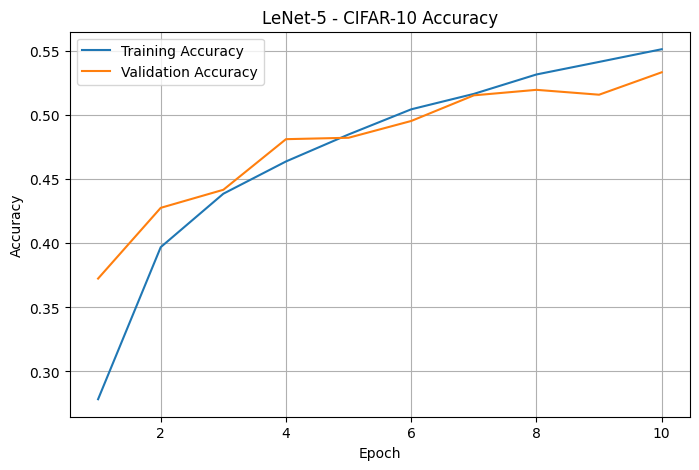

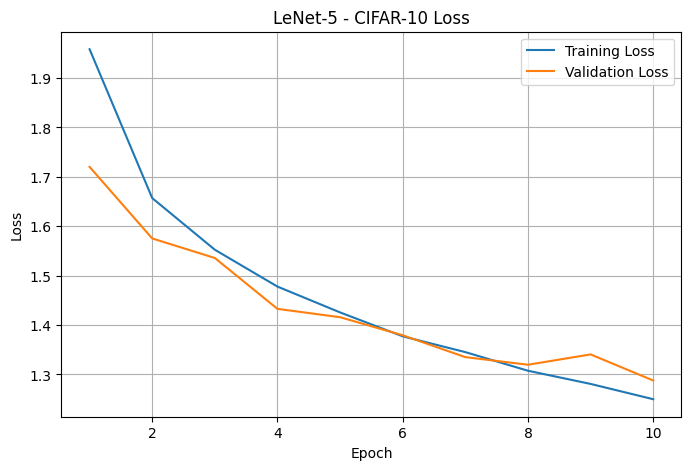

In [ ]:

# ============================================================
# CELL 14 — train LeNet on CIFAR-10
# ============================================================

lenet_cifar10 = build_lenet(10)

history_lenet10, times_lenet10, loss_lenet10, acc_lenet10, top5_lenet10 = train_model(
    lenet_cifar10,
    x_train10,
    y_train10,
    x_test10,
    y_test10
)

print(f"Top-1 accuracy: {acc_lenet10 * 100:.2f}%")
print(f"Top-5 accuracy: {top5_lenet10 * 100:.2f}%")
print(f"Accuracy drop Top-1: {accuracy_drop(acc_lenet10):.2f}%")
print(f"Accuracy drop Top-5: {accuracy_drop(top5_lenet10):.2f}%")
print(f"Average epoch time: {np.mean(times_lenet10):.2f} seconds")

# Print training time for every epoch
for epoch, t in enumerate(times_lenet10, start=1):
    print(f"Epoch {epoch}: {t:.2f} seconds")

plot_history(history_lenet10, "LeNet-5", "CIFAR-10")


391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - loss: 4.2958 - top1_accuracy: 0.0433 - top5_accuracy: 0.1627 - val_loss: 3.9379 - val_top1_accuracy: 0.0893 - val_top5_accuracy: 0.2969
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - loss: 3.7755 - top1_accuracy: 0.1217 - top5_accuracy: 0.3444 - val_loss: 3.6566 - val_top1_accuracy: 0.1469 - val_top5_accuracy: 0.3857
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - loss: 3.5608 - top1_accuracy: 0.1593 - top5_accuracy: 0.4116 - val_loss: 3.5257 - val_top1_accuracy: 0.1658 - val_top5_accuracy: 0.4183
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - loss: 3.4329 - top1_accuracy: 0.1843 - top5_accuracy: 0.4454 - val_loss: 3.4494 - val_top1_accuracy: 0.1894 - val_top5_accuracy: 0.4394
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - loss: 3.3388 - top1_accuracy: 0.2039 - top5_accuracy: 0.4722 - val_loss: 3.3481 - val_top1_accuracy: 0.1982 - val_top5_accuracy: 0.4679
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - loss: 3.2590 - top1_accuracy: 0.2188 - top5_accura

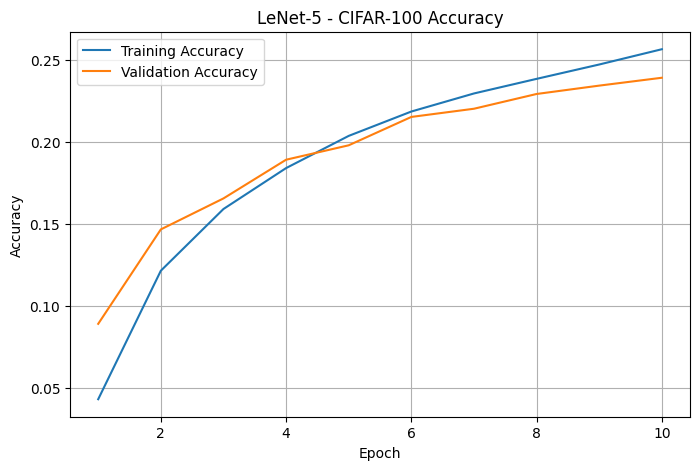

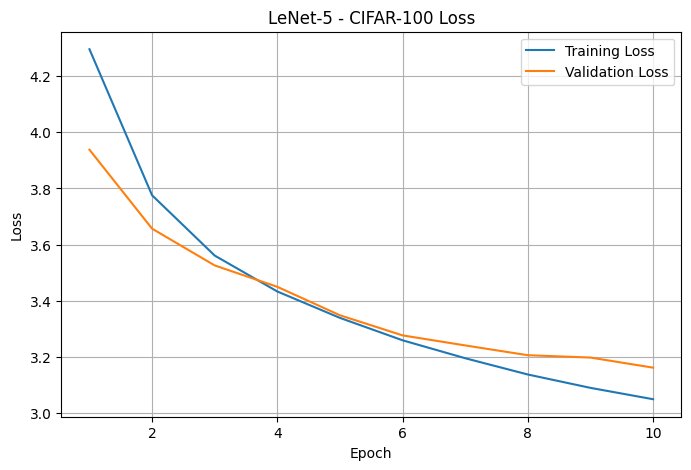

In [ ]:
# ============================================================
# CELL 15 —train LeNet on CIFAR-100
# ============================================================
lenet_cifar100 = build_lenet(100)

history_lenet100, times_lenet100, loss_lenet100, acc_lenet100, top5_lenet100 = train_model(
    lenet_cifar100,
    x_train100,
    y_train100,
    x_test100,
    y_test100
)

print(f"Top-1 accuracy: {acc_lenet100 * 100:.2f}%")
print(f"Top-5 accuracy: {top5_lenet100 * 100:.2f}%")
print(f"Accuracy drop Top-1 : {accuracy_drop(acc_lenet100):.2f}%")
print(f"Accuracy drop Top-5 : {accuracy_drop(top5_lenet100):.2f}%")
print(f"Average epoch time: {np.mean(times_lenet100):.2f} seconds")

# Print training time for every epoch
for epoch, t in enumerate(times_lenet100, start=1):
    print(f"Epoch {epoch}: {t:.2f} seconds")

plot_history(history_lenet100, "LeNet-5", "CIFAR-100")


391/391 ━━━━━━━━━━━━━━━━━━━━ 3023s 8s/step - loss: 2.0315 - top1_accuracy: 0.2285 - top5_accuracy: 0.7650 - val_loss: 1.7498 - val_top1_accuracy: 0.3249 - val_top5_accuracy: 0.8700
391/391 ━━━━━━━━━━━━━━━━━━━━ 2948s 8s/step - loss: 1.6293 - top1_accuracy: 0.3952 - top5_accuracy: 0.8923 - val_loss: 1.5515 - val_top1_accuracy: 0.4344 - val_top5_accuracy: 0.9081
391/391 ━━━━━━━━━━━━━━━━━━━━ 2938s 8s/step - loss: 1.4352 - top1_accuracy: 0.4767 - top5_accuracy: 0.9244 - val_loss: 1.3556 - val_top1_accuracy: 0.5083 - val_top5_accuracy: 0.9347
391/391 ━━━━━━━━━━━━━━━━━━━━ 2984s 8s/step - loss: 1.3103 - top1_accuracy: 0.5238 - top5_accuracy: 0.9397 - val_loss: 1.2970 - val_top1_accuracy: 0.5390 - val_top5_accuracy: 0.9426
391/391 ━━━━━━━━━━━━━━━━━━━━ 2974s 8s/step - loss: 1.2035 - top1_accuracy: 0.5658 - top5_accuracy: 0.9502 - val_loss: 1.2121 - val_top1_accuracy: 0.5676 - val_top5_accuracy: 0.9476
391/391 ━━━━━━━━━━━━━━━━━━━━ 2966s 8s/step - loss: 1.1112 - top1_accuracy: 0.6034 - top5_accura

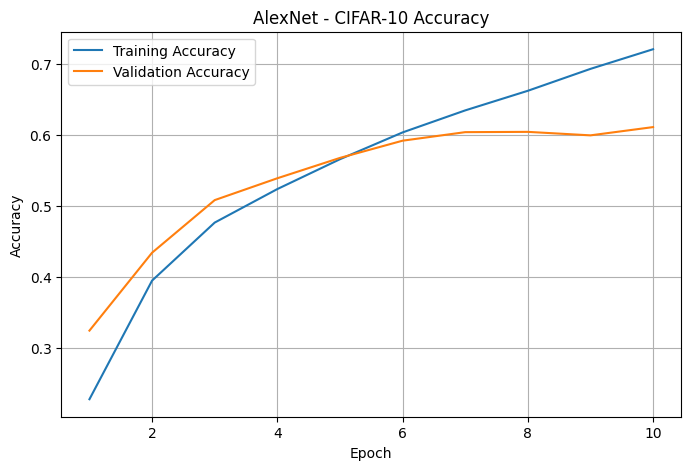

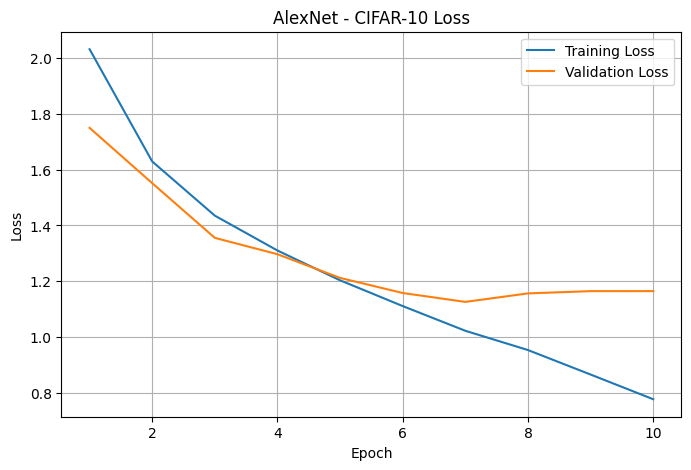

In [ ]:
# ============================================================
# CELL 16 — train AlexNet on CIFAR-10
# ============================================================
alexnet_cifar10 = build_alexnet(10)

history_alexnet10, times_alexnet10, loss_alexnet10, acc_alexnet10, top5_alexnet10 = train_model(
    alexnet_cifar10,
    x_train10,
    y_train10,
    x_test10,
    y_test10
)

print(f"Top-1 accuracy: {acc_alexnet10 * 100:.2f}%")
print(f"Top-5 accuracy: {top5_alexnet10 * 100:.2f}%")
print(f"Accuracy drop Top-1: {accuracy_drop(acc_alexnet10):.2f}%")
print(f"Accuracy drop Top-5: {accuracy_drop(top5_alexnet10):.2f}%")
print(f"Average epoch time: {np.mean(times_alexnet10):.2f} seconds")

# Print training time for every epoch
for epoch, t in enumerate(times_alexnet10, start=1):
    print(f"Epoch {epoch}: {t:.2f} seconds")

plot_history(history_alexnet10, "AlexNet", "CIFAR-10")

391/391 ━━━━━━━━━━━━━━━━━━━━ 2583s 7s/step - loss: 4.4705 - top1_accuracy: 0.0201 - top5_accuracy: 0.0927 - val_loss: 4.1967 - val_top1_accuracy: 0.0415 - val_top5_accuracy: 0.1915
391/391 ━━━━━━━━━━━━━━━━━━━━ 2608s 7s/step - loss: 4.0481 - top1_accuracy: 0.0678 - top5_accuracy: 0.2373 - val_loss: 3.9569 - val_top1_accuracy: 0.0846 - val_top5_accuracy: 0.2750
391/391 ━━━━━━━━━━━━━━━━━━━━ 2589s 7s/step - loss: 3.8137 - top1_accuracy: 0.1087 - top5_accuracy: 0.3177 - val_loss: 3.7041 - val_top1_accuracy: 0.1283 - val_top5_accuracy: 0.3475
391/391 ━━━━━━━━━━━━━━━━━━━━ 2579s 7s/step - loss: 3.6259 - top1_accuracy: 0.1388 - top5_accuracy: 0.3748 - val_loss: 3.6182 - val_top1_accuracy: 0.1424 - val_top5_accuracy: 0.3839
391/391 ━━━━━━━━━━━━━━━━━━━━ 2571s 7s/step - loss: 3.4883 - top1_accuracy: 0.1642 - top5_accuracy: 0.4124 - val_loss: 3.4958 - val_top1_accuracy: 0.1686 - val_top5_accuracy: 0.4172
391/391 ━━━━━━━━━━━━━━━━━━━━ 2571s 7s/step - loss: 3.3619 - top1_accuracy: 0.1886 - top5_accura

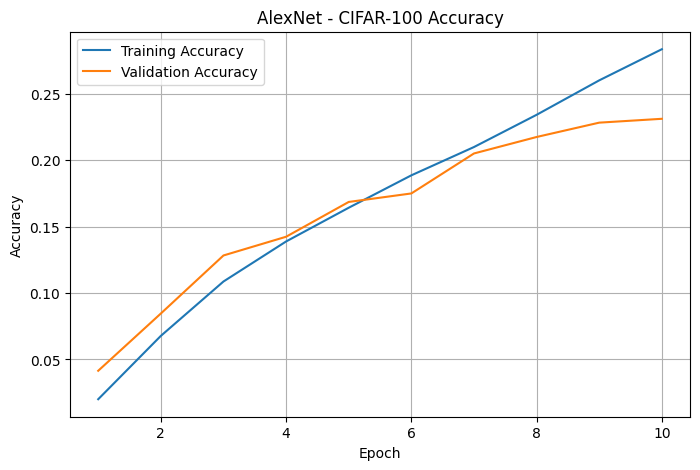

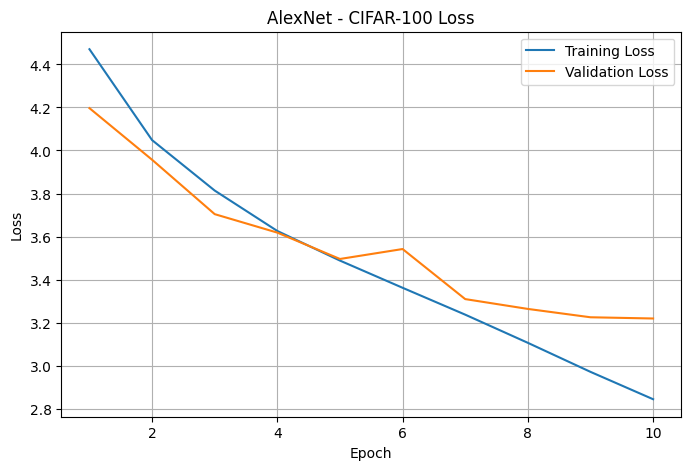

In [ ]:
# ============================================================
# CELL 17 — train AlexNet on CIFAR-100
# ============================================================
alexnet_cifar100 = build_alexnet(100)

history_alexnet100, times_alexnet100, loss_alexnet100, acc_alexnet100, top5_alexnet100 = train_model(
    alexnet_cifar100,
    x_train100,
    y_train100,
    x_test100,
    y_test100
)

print(f"Top-1 accuracy: {acc_alexnet100 * 100:.2f}%")
print(f"Top-5 accuracy: {top5_alexnet100 * 100:.2f}%")
print(f"Accuracy drop Top-1: {accuracy_drop(acc_alexnet100):.2f}%")
print(f"Accuracy drop Top-5: {accuracy_drop(top5_alexnet100):.2f}%")
print(f"Average epoch time: {np.mean(times_alexnet100):.2f} seconds")

# Print training time for every epoch
for epoch, t in enumerate(times_alexnet100, start=1):
    print(f"Epoch {epoch}: {t:.2f} seconds")

plot_history(history_alexnet100, "AlexNet", "CIFAR-100")

In [ ]:
# ============================================================
# CELL 18 — train VGG16 on CIFAR-10
# ============================================================
vgg16_cifar10 = build_vgg16(10)

history_vgg16_10, times_vgg16_10, loss_vgg16_10, acc_vgg16_10, top5_vgg16_10 = train_model(
    vgg16_cifar10,
    x_train10,
    y_train10,
    x_test10,
    y_test10
)

print(f"Top-1 accuracy: {acc_vgg16_10 * 100:.2f}%")
print(f"Top-5 accuracy: {top5_vgg16_10 * 100:.2f}%")
print(f"Accuracy drop Top-1: {accuracy_drop(acc_vgg16_10):.2f}%")
print(f"Accuracy drop Top-5: {accuracy_drop(top5_vgg16_10):.2f}%")
print(f"Average epoch time: {np.mean(times_vgg16_10):.2f} seconds")

# Print training time for every epoch
for epoch, t in enumerate(times_vgg16_10, start=1):
    print(f"Epoch {epoch}: {t:.2f} seconds")

plot_history(history_vgg16_10, "VGG16", "CIFAR-10")

In [ ]:
# ============================================================
# CELL 19 — train VGG16 on CIFAR-100
# ============================================================
vgg16_cifar100 = build_vgg16(100)

history_vgg16_100, times_vgg16_100, loss_vgg16_100, acc_vgg16_100, top5_vgg16_100 = train_model(
    vgg16_cifar100,
    x_train100,
    y_train100,
    x_test100,
    y_test100
)

print(f"Top-1 accuracy: {acc_vgg16_100 * 100:.2f}%")
print(f"Top-5 accuracy: {top5_vgg16_100 * 100:.2f}%")
print(f"Accuracy drop Top-1: {accuracy_drop(acc_vgg16_100):.2f}%")
print(f"Accuracy drop Top-5: {accuracy_drop(top5_vgg16_100):.2f}%")
print(f"Average epoch time: {np.mean(times_vgg16_100):.2f} seconds")

# Print training time for every epoch
for epoch, t in enumerate(times_vgg16_100, start=1):
    print(f"Epoch {epoch}: {t:.2f} seconds")

plot_history(history_vgg16_100, "VGG16", "CIFAR-100")

391/391 ━━━━━━━━━━━━━━━━━━━━ 6811s 17s/step - loss: 4.6059 - top1_accuracy: 0.0090 - top5_accuracy: 0.0454 - val_loss: 4.6052 - val_top1_accuracy: 0.0100 - val_top5_accuracy: 0.0500
391/391 ━━━━━━━━━━━━━━━━━━━━ 6791s 17s/step - loss: 4.6056 - top1_accuracy: 0.0092 - top5_accuracy: 0.0428 - val_loss: 4.6052 - val_top1_accuracy: 0.0100 - val_top5_accuracy: 0.0500
391/391 ━━━━━━━━━━━━━━━━━━━━ 6710s 17s/step - loss: 4.6056 - top1_accuracy: 0.0087 - top5_accuracy: 0.0447 - val_loss: 4.6052 - val_top1_accuracy: 0.0100 - val_top5_accuracy: 0.0500
391/391 ━━━━━━━━━━━━━━━━━━━━ 6500s 17s/step - loss: 4.6056 - top1_accuracy: 0.0080 - top5_accuracy: 0.0448 - val_loss: 4.6052 - val_top1_accuracy: 0.0100 - val_top5_accuracy: 0.0500
391/391 ━━━━━━━━━━━━━━━━━━━━ 7017s 18s/step - loss: 4.6056 - top1_accuracy: 0.0091 - top5_accuracy: 0.0449 - val_loss: 4.6052 - val_top1_accuracy: 0.0100 - val_top5_accuracy: 0.0500
226/391 ━━━━━━━━━━━━━━━━━━━━ 51:06 19s/step - loss: 4.6053 - top1_accuracy: 0.0084 - top5_

In [ ]:
# ============================================================
# CELL 20 — Save results
# ============================================================

results.to_csv("results.csv", index=False)
parameter_table.to_csv("parameter_comparison.csv", index=False)

print("Notebook setup complete.")
print("Next: verify the three model summaries before running training.")
